In [91]:
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
Path("../figs/eda/transactions").mkdir(parents=True, exist_ok=True)

con = duckdb.connect("../data/capstone.duckdb")

### Range of data - transactions and customers

In [52]:
query = con.execute("""
    SELECT 
        COUNT(*) AS total_transactions,
        COUNT(DISTINCT CustomerID) AS unique_customers,
        MIN(Transaction_Date) AS earliest_date,
        MAX(Transaction_Date) AS latest_date
    FROM silver.transactions
""").fetchone()

print(f"Total transactions:  {query[0]:,}")
print(f"Unique customers:    {query[1]:,}")
print(f"Date range:          {query[2]} to {query[3]}")

Total transactions:  8,137,375
Unique customers:    128,071
Date range:          2025-09-08 to 2026-01-24


### Amount of transactions

In [53]:
# Transaction amount distribution
query = con.execute("""
    SELECT 
        ROUND(MIN(Amount_Completed), 2) AS min_amt,
        ROUND(MAX(Amount_Completed), 2) AS max_amt,
        ROUND(AVG(Amount_Completed), 2) AS avg_amt,
        ROUND(MEDIAN(Amount_Completed), 2) AS median_amt
    FROM silver.transactions
""").fetchone()

print(f"Min:    ${query[0]:,}")
print(f"Max:    ${query[1]:,}")
print(f"Mean:   ${query[2]:,}")
print(f"Median: ${query[3]:,}")

Min:    $0.01
Max:    $95,000.0
Mean:   $50.09
Median: $21.64


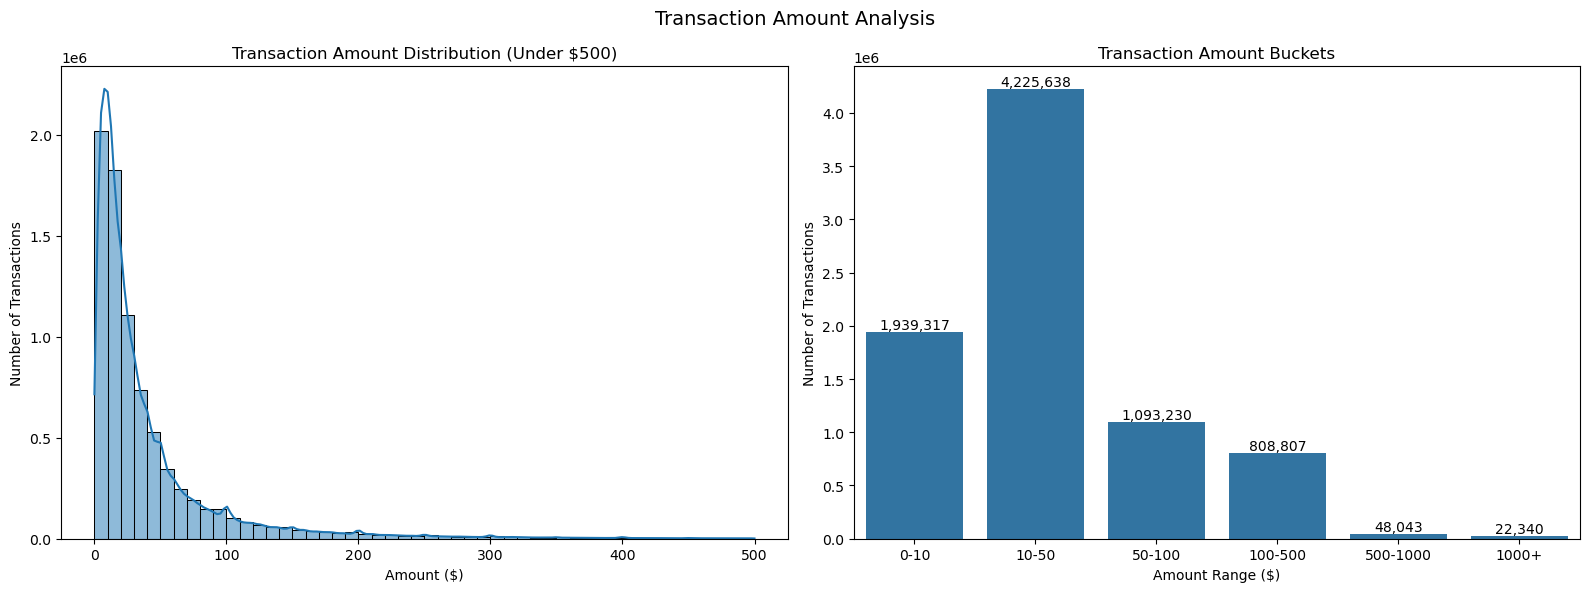

In [54]:
# Amount distribution
df_amount = con.execute("""
    SELECT Amount_Completed
    FROM silver.transactions
    WHERE Amount_Completed IS NOT NULL
""").fetchdf()

# Transaction amount buckets
df_buckets = con.execute("""
    SELECT 
        CASE 
            WHEN Amount_Completed < 10 THEN '0-10'
            WHEN Amount_Completed < 50 THEN '10-50'
            WHEN Amount_Completed < 100 THEN '50-100'
            WHEN Amount_Completed < 500 THEN '100-500'
            WHEN Amount_Completed < 1000 THEN '500-1000'
            ELSE '1000+'
        END AS bucket,
        COUNT(*) AS count
    FROM silver.transactions
    GROUP BY bucket
    ORDER BY MIN(Amount_Completed)
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

filtered = df_amount[df_amount['Amount_Completed'] < 500]
sns.histplot(data=filtered, x='Amount_Completed', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution (Under $500)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Number of Transactions')

sns.barplot(data=df_buckets, x='bucket', y='count', ax=axes[1])
axes[1].set_title('Transaction Amount Buckets')
axes[1].set_xlabel('Amount Range ($)')
axes[1].set_ylabel('Number of Transactions')
for i, row in df_buckets.iterrows():
    axes[1].text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')

plt.suptitle('Transaction Amount Analysis', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_amounts.png", dpi=150, bbox_inches='tight')
plt.show()

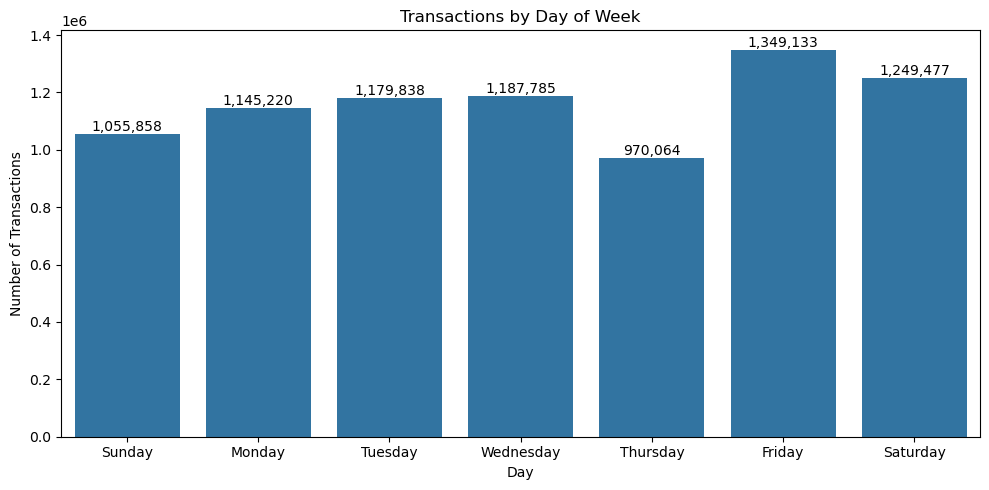

In [55]:
# Weekly classification (day of week)
df_weekly = con.execute("""
    SELECT DAYNAME(Transaction_Date) AS day_of_week, 
           DAYOFWEEK(Transaction_Date) AS day_num,
           COUNT(*) AS count
    FROM silver.transactions
    GROUP BY day_of_week, day_num
    ORDER BY day_num
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_weekly, x='day_of_week', y='count', ax=ax)
ax.set_title('Transactions by Day of Week')
ax.set_xlabel('Day')
ax.set_ylabel('Number of Transactions')
for i, row in df_weekly.iterrows():
    ax.text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_weekdays.png", dpi=150, bbox_inches='tight')
plt.show()

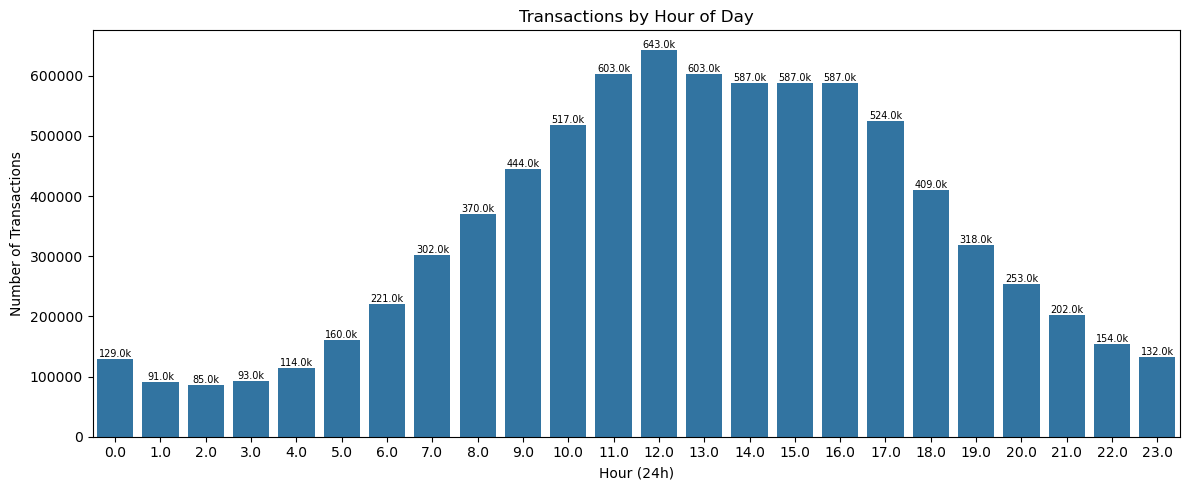

In [56]:
# Hourly classification
df_hourly = con.execute("""
    SELECT FLOOR(Time_Local_hhmmss / 10000) AS hour, 
           COUNT(*) AS count
    FROM silver.transactions
    WHERE Time_Local_hhmmss IS NOT NULL
    GROUP BY hour
    ORDER BY hour
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_hourly, x='hour', y='count', ax=ax)
ax.set_title('Transactions by Hour of Day')
ax.set_xlabel('Hour (24h)')
ax.set_ylabel('Number of Transactions')
for i, row in df_hourly.iterrows():
    ax.text(i, row['count'], f"{row['count']//1000}k", ha='center', va='bottom', fontsize=7)
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_hours.png", dpi=150, bbox_inches='tight')
plt.show()

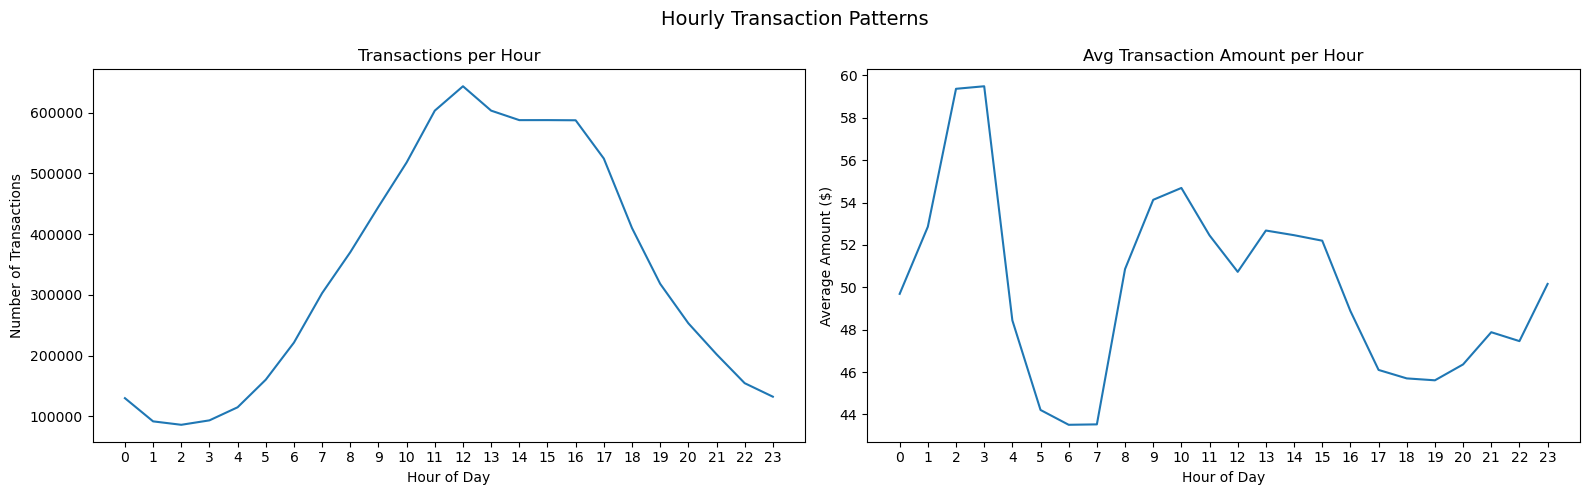

In [57]:
df_hourly_amount = con.execute("""
    SELECT FLOOR(Time_Local_hhmmss / 10000) AS hour, 
           COUNT(*) AS count,
           ROUND(SUM(Amount_Completed), 2) AS total_amount,
           ROUND(AVG(Amount_Completed), 2) AS avg_amount
    FROM silver.transactions
    WHERE Time_Local_hhmmss IS NOT NULL
    GROUP BY hour
    ORDER BY hour
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df_hourly_amount['hour'], df_hourly_amount['count'])
axes[0].set_title('Transactions per Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(range(0, 24))

axes[1].plot(df_hourly_amount['hour'], df_hourly_amount['avg_amount'])
axes[1].set_title('Avg Transaction Amount per Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Amount ($)')
axes[1].set_xticks(range(0, 24))

plt.suptitle('Hourly Transaction Patterns', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_hourly.png", dpi=150, bbox_inches='tight')
plt.show()

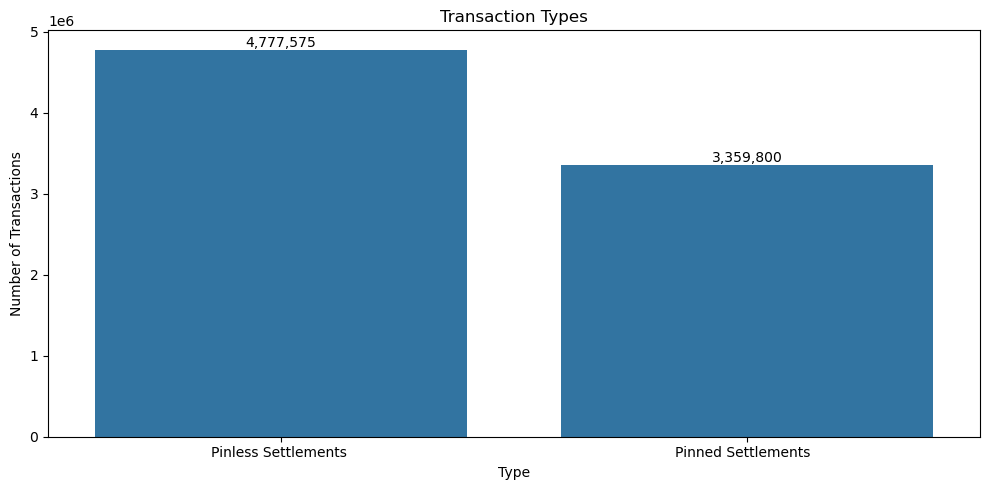

In [58]:
# Transaction types
df_txn_type = con.execute("""
    SELECT Transaction_Type, Transaction_Type_Description, COUNT(*) AS count
    FROM silver.transactions
    GROUP BY Transaction_Type, Transaction_Type_Description
    ORDER BY count DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_txn_type, x='Transaction_Type_Description', y='count', ax=ax)
ax.set_title('Transaction Types')
ax.set_xlabel('Type')
ax.set_ylabel('Number of Transactions')
for i, row in df_txn_type.iterrows():
    ax.text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_settlements.png", dpi=150, bbox_inches='tight')
plt.show()

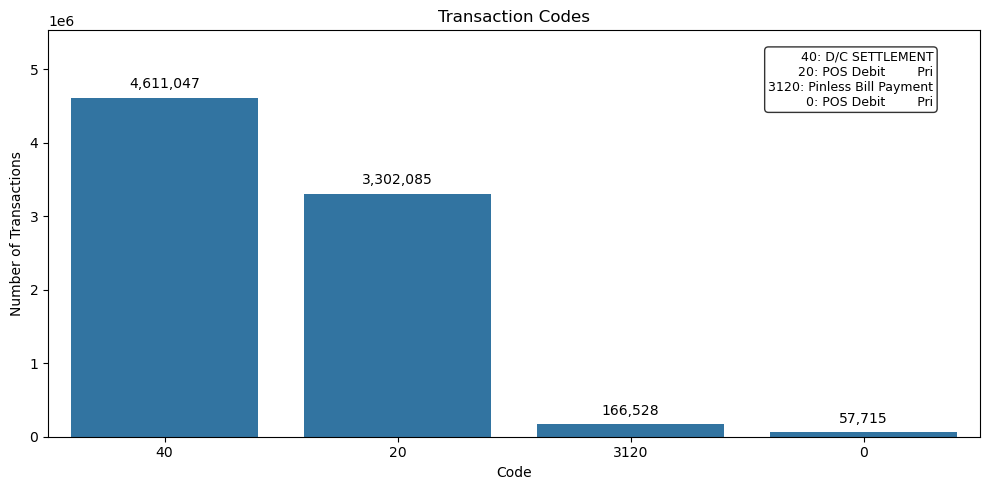

In [59]:
# Transaction codes
df_txn_code = con.execute("""
    SELECT Transaction_Code, Transaction_Code_Description, COUNT(*) AS count
    FROM silver.transactions
    GROUP BY Transaction_Code, Transaction_Code_Description
    ORDER BY count DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_txn_code, x='Transaction_Code', y='count', ax=ax)
ax.set_title('Transaction Codes')
ax.set_xlabel('Code')
ax.set_ylabel('Number of Transactions')
ax.set_ylim(0, df_txn_code['count'].max() * 1.2)
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x):,}", padding=5)

legend_text = '\n'.join([f"{row['Transaction_Code']}: {row['Transaction_Code_Description']}" 
                         for _, row in df_txn_code.iterrows()])
ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_codes.png", dpi=150, bbox_inches='tight')
plt.show()

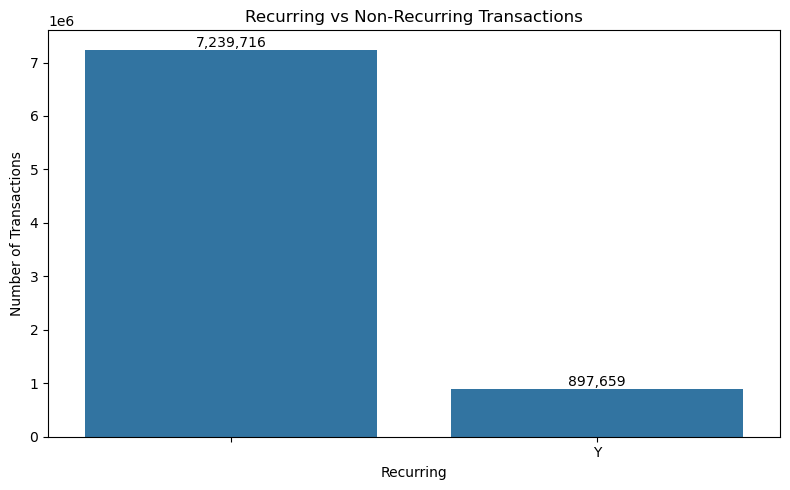

In [60]:
# Recurring transactions
df_recurring = con.execute("""
    SELECT Recurring_Trxn, COUNT(*) AS count
    FROM silver.transactions
    GROUP BY Recurring_Trxn
    ORDER BY count DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_recurring, x='Recurring_Trxn', y='count', ax=ax)
ax.set_title('Recurring vs Non-Recurring Transactions')
ax.set_xlabel('Recurring')
ax.set_ylabel('Number of Transactions')
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x):,}")
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_recurring.png", dpi=150, bbox_inches='tight')
plt.show()

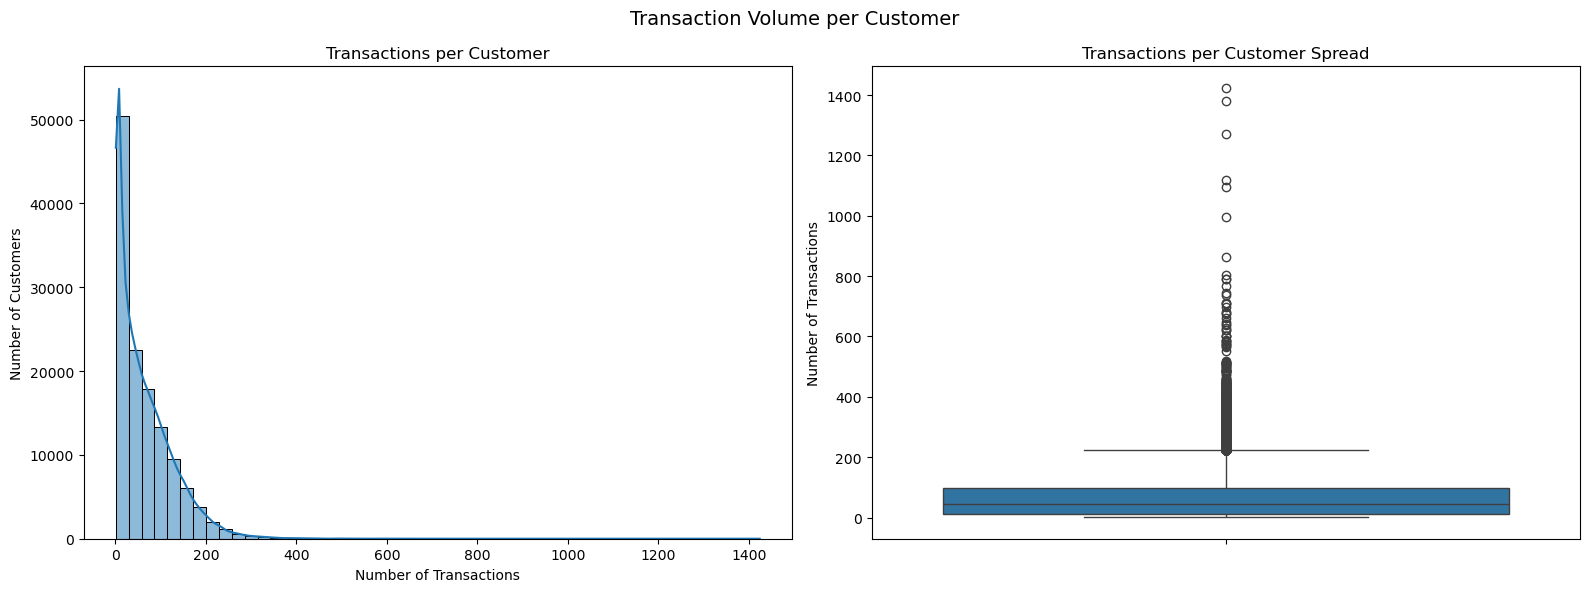

In [61]:
df_txn_per_customer = con.execute("""
    SELECT CustomerID, COUNT(*) AS txn_count
    FROM silver.transactions
    GROUP BY CustomerID
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df_txn_per_customer, x='txn_count', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Transactions per Customer')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Number of Customers')

sns.boxplot(data=df_txn_per_customer, y='txn_count', ax=axes[1])
axes[1].set_title('Transactions per Customer Spread')
axes[1].set_ylabel('Number of Transactions')

plt.suptitle('Transaction Volume per Customer', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_per_customers_a.png", dpi=150, bbox_inches='tight')
plt.show()

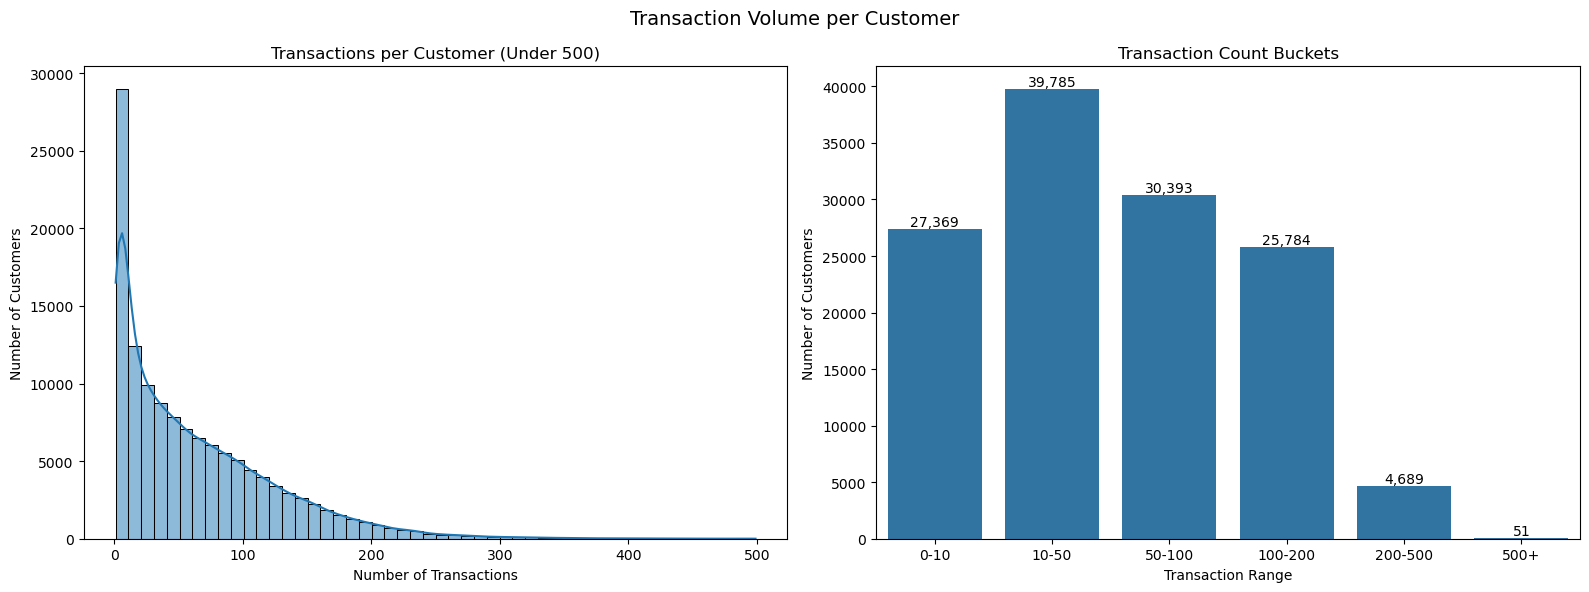

In [62]:
# Transactions per customer
df_txn_buckets = con.execute("""
    SELECT 
        CASE 
            WHEN txn_count < 10 THEN '0-10'
            WHEN txn_count < 50 THEN '10-50'
            WHEN txn_count < 100 THEN '50-100'
            WHEN txn_count < 200 THEN '100-200'
            WHEN txn_count < 500 THEN '200-500'
            ELSE '500+'
        END AS bucket,
        COUNT(*) AS count
    FROM (
        SELECT CustomerID, COUNT(*) AS txn_count
        FROM silver.transactions
        GROUP BY CustomerID
    )
    GROUP BY bucket
    ORDER BY MIN(txn_count)
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

filtered_txn = df_txn_per_customer[df_txn_per_customer['txn_count'] < 500]
sns.histplot(data=filtered_txn, x='txn_count', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Transactions per Customer (Under 500)')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Number of Customers')

sns.barplot(data=df_txn_buckets, x='bucket', y='count', ax=axes[1])
axes[1].set_title('Transaction Count Buckets')
axes[1].set_xlabel('Transaction Range')
axes[1].set_ylabel('Number of Customers')
ax = axes[1]
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x):,}")

plt.suptitle('Transaction Volume per Customer', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_per_customers_b.png", dpi=150, bbox_inches='tight')
plt.show()

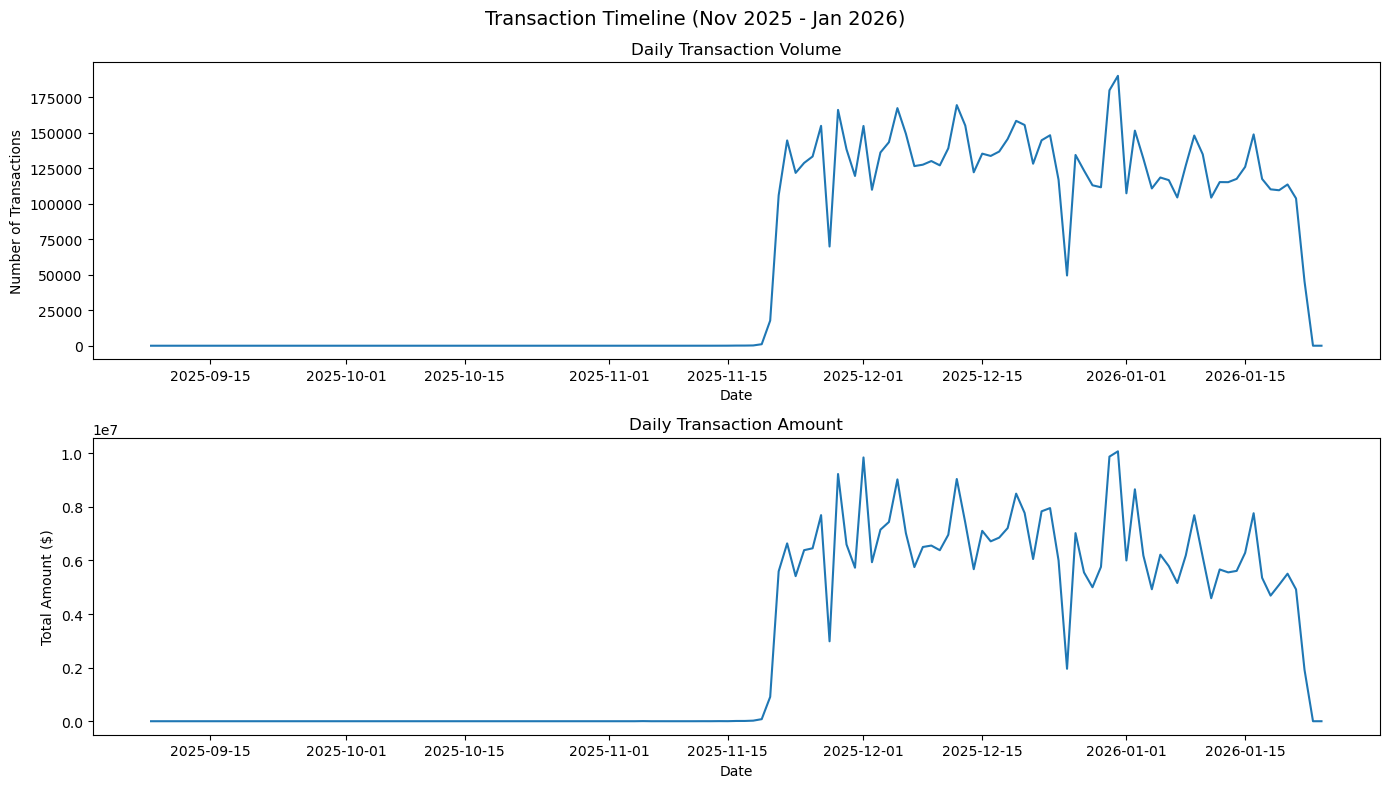

In [63]:
# Transaction timeline (daily volume)
df_timeline = con.execute("""
    SELECT Transaction_Date, COUNT(*) AS count, 
           ROUND(SUM(Amount_Completed), 2) AS total_amount
    FROM silver.transactions
    GROUP BY Transaction_Date
    ORDER BY Transaction_Date
""").fetchdf()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_timeline['Transaction_Date'], df_timeline['count'])
axes[0].set_title('Daily Transaction Volume')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Transactions')

axes[1].plot(df_timeline['Transaction_Date'], df_timeline['total_amount'])
axes[1].set_title('Daily Transaction Amount')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Amount ($)')

plt.suptitle('Transaction Timeline (Nov 2025 - Jan 2026)', fontsize=14)
plt.tight_layout()
plt.show()

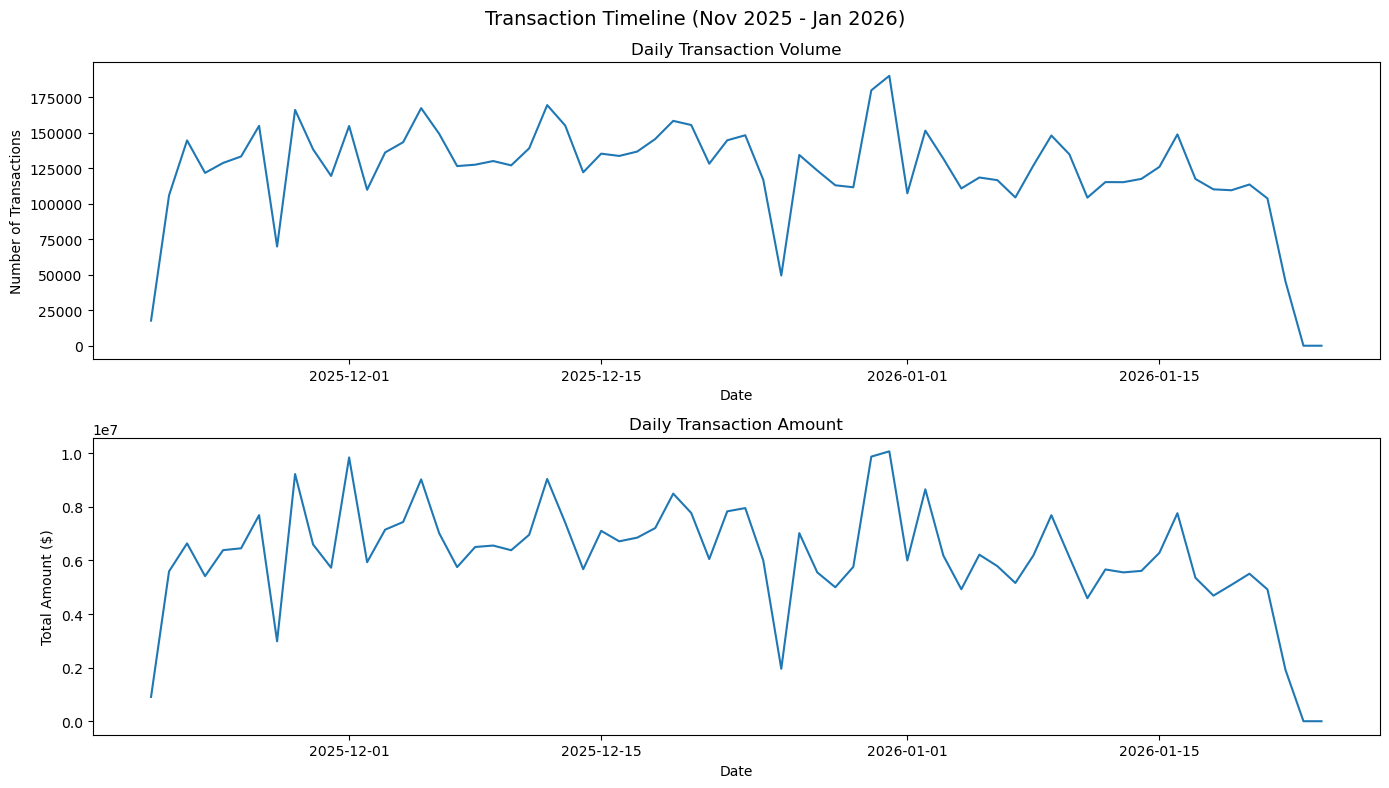

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

nov_onwards = df_timeline[df_timeline['Transaction_Date'] >= '2025-11-20']

axes[0].plot(nov_onwards['Transaction_Date'], nov_onwards['count'])
axes[0].set_title('Daily Transaction Volume')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Transactions')

axes[1].plot(nov_onwards['Transaction_Date'], nov_onwards['total_amount'])
axes[1].set_title('Daily Transaction Amount')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Amount ($)')

plt.suptitle('Transaction Timeline (Nov 2025 - Jan 2026)', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_timeline.png", dpi=150, bbox_inches='tight')
plt.show()

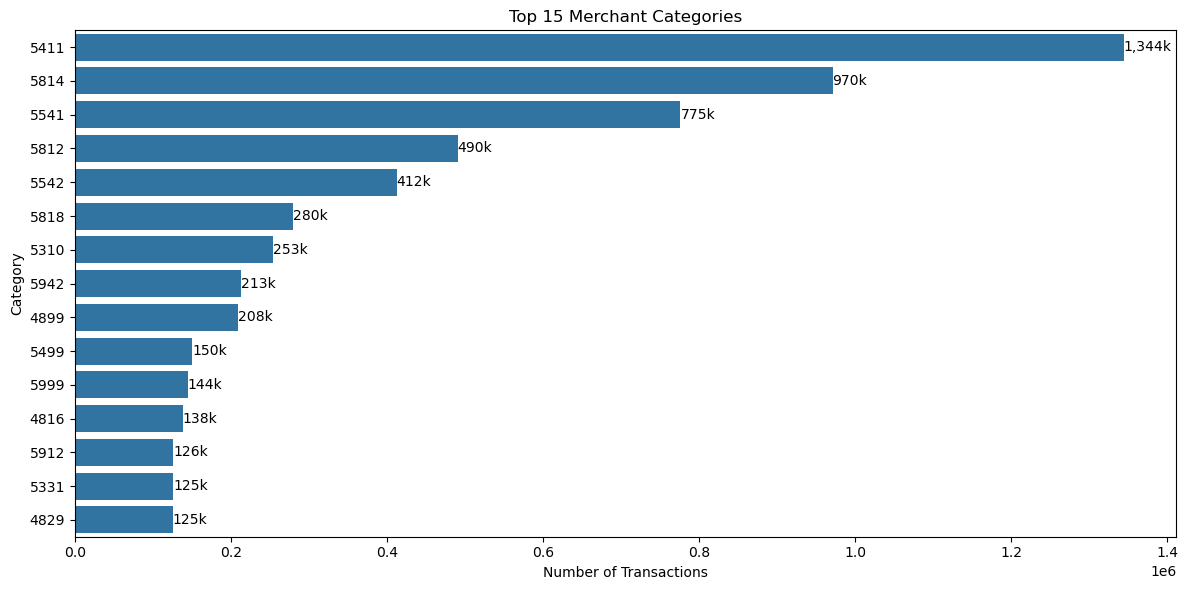

In [97]:
# Merchant category breakdown
df_merchant_cat = con.execute("""
    SELECT Merchant_Category, COUNT(*) AS count,
           ROUND(AVG(Amount_Completed), 2) AS avg_amount
    FROM silver.transactions
    WHERE Merchant_Category IS NOT NULL
    GROUP BY Merchant_Category
    ORDER BY count DESC
    LIMIT 15
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_merchant_cat, x='count', y='Merchant_Category', ax=ax, orient='h')
ax.set_title('Top 15 Merchant Categories')
ax.set_xlabel('Number of Transactions')
ax.set_ylabel('Category')
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x)//1000:,}k")
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_merchants_a.png", dpi=150, bbox_inches='tight')
plt.show()

                 category  txn_count  avg_amount
0                  Dining    1541987       23.53
1                 Grocery    1513183       50.86
2                     Gas    1188197       25.22
3                  Retail     973580       49.96
4                   Other     476853      126.71
5   Digital/Subscriptions     476337       17.95
6           Telecom/Cable     289457       55.22
7   Electronics/Computers     275133       42.64
8      Financial Services     247389      143.81
9   Entertainment/Leisure     211114       52.08
10             Healthcare     171099       50.57
11             Automotive     131616       75.21
12          Home/Hardware     130801       97.28
13          Personal Care     114138       68.92
14         Transportation     103357       18.12
15   Government/Community      95945       77.39
16               Clothing      92382       68.87
17                   Pets      53901       92.45
18              Utilities      50906      249.02


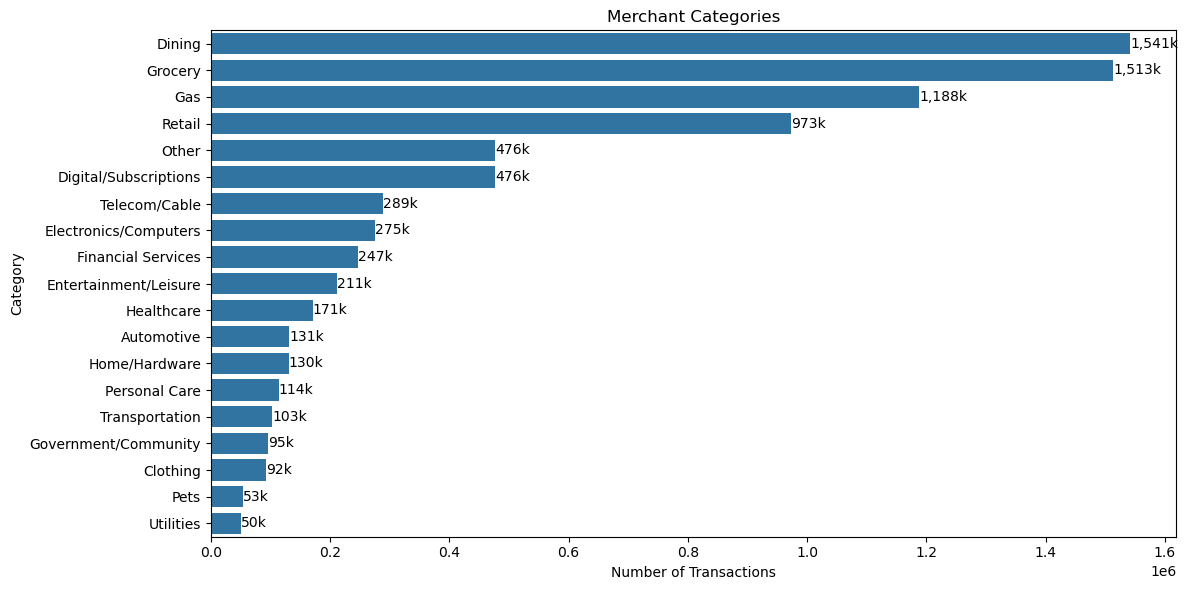

In [104]:
df_mcc = con.execute("""
    SELECT 
        m.category,
        COUNT(*) AS txn_count,
        ROUND(AVG(t.Amount_Completed), 2) AS avg_amount
    FROM silver.transactions t
    LEFT JOIN gold.mrt_mcc_categories m
        ON t.Merchant_Category = m.merchant_category
    GROUP BY m.category
    ORDER BY txn_count DESC
""").fetchdf()

print(df_mcc)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_mcc, x='txn_count', y='category', ax=ax, orient='h')
ax.set_title('Merchant Categories')
ax.set_xlabel('Number of Transactions')
ax.set_ylabel('Category')
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x)//1000:,}k")
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_merchants_b.png", dpi=150, bbox_inches='tight')
plt.show()

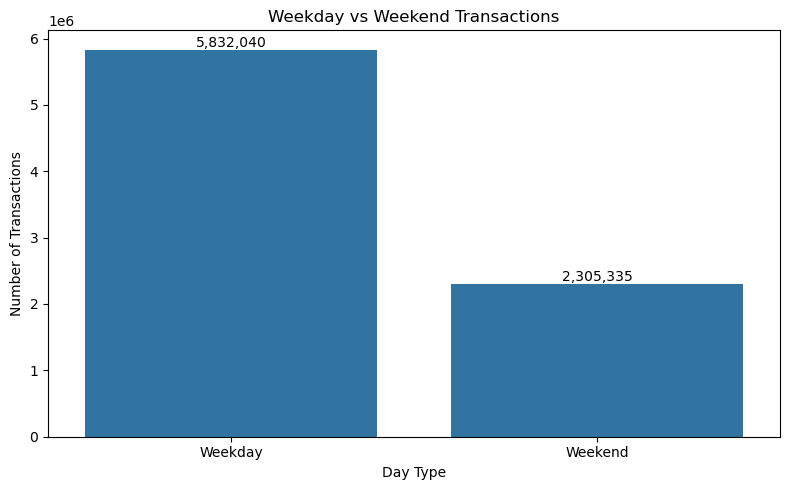

In [66]:
# Weekday vs weekend
df_weekday_weekend = con.execute("""
    SELECT 
        CASE WHEN DAYOFWEEK(Transaction_Date) IN (0, 6) THEN 'Weekend' ELSE 'Weekday' END AS day_type,
        COUNT(*) AS count,
        ROUND(AVG(Amount_Completed), 2) AS avg_amount
    FROM silver.transactions
    GROUP BY day_type
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_weekday_weekend, x='day_type', y='count', ax=ax)
ax.set_title('Weekday vs Weekend Transactions')
ax.set_xlabel('Day Type')
ax.set_ylabel('Number of Transactions')
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x):,}")
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txn_days.png", dpi=150, bbox_inches='tight')
plt.show()

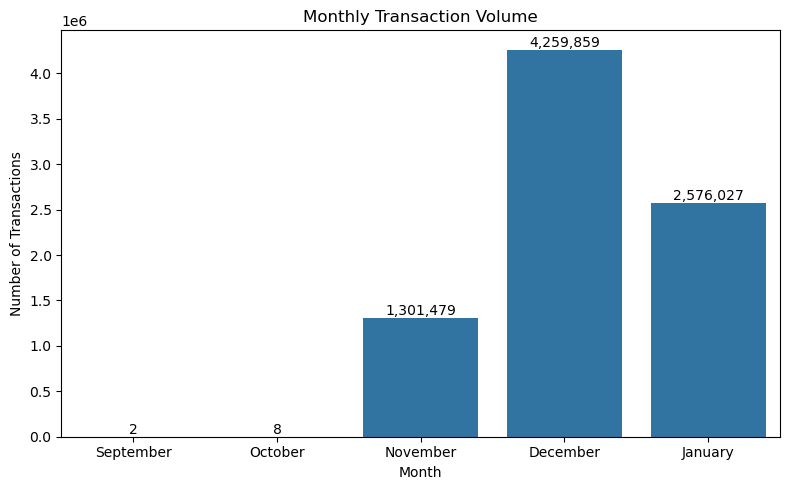

In [67]:
# Monthly volume (Nov vs Dec vs Jan)
df_monthly = con.execute("""
    SELECT MONTHNAME(Transaction_Date) AS month,
           MONTH(Transaction_Date) AS month_num,
           COUNT(*) AS count,
           ROUND(SUM(Amount_Completed), 2) AS total_amount
    FROM silver.transactions
    GROUP BY month, month_num
    ORDER BY month_num
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 5))
month_order = ['September', 'October', 'November', 'December', 'January']
sns.barplot(data=df_monthly, x='month', y='count', ax=ax, order=month_order)
ax.set_title('Monthly Transaction Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Transactions')
ax.bar_label(ax.containers[0], fmt=lambda x: f"{int(x):,}")
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txnmonths.png", dpi=150, bbox_inches='tight')
plt.show()

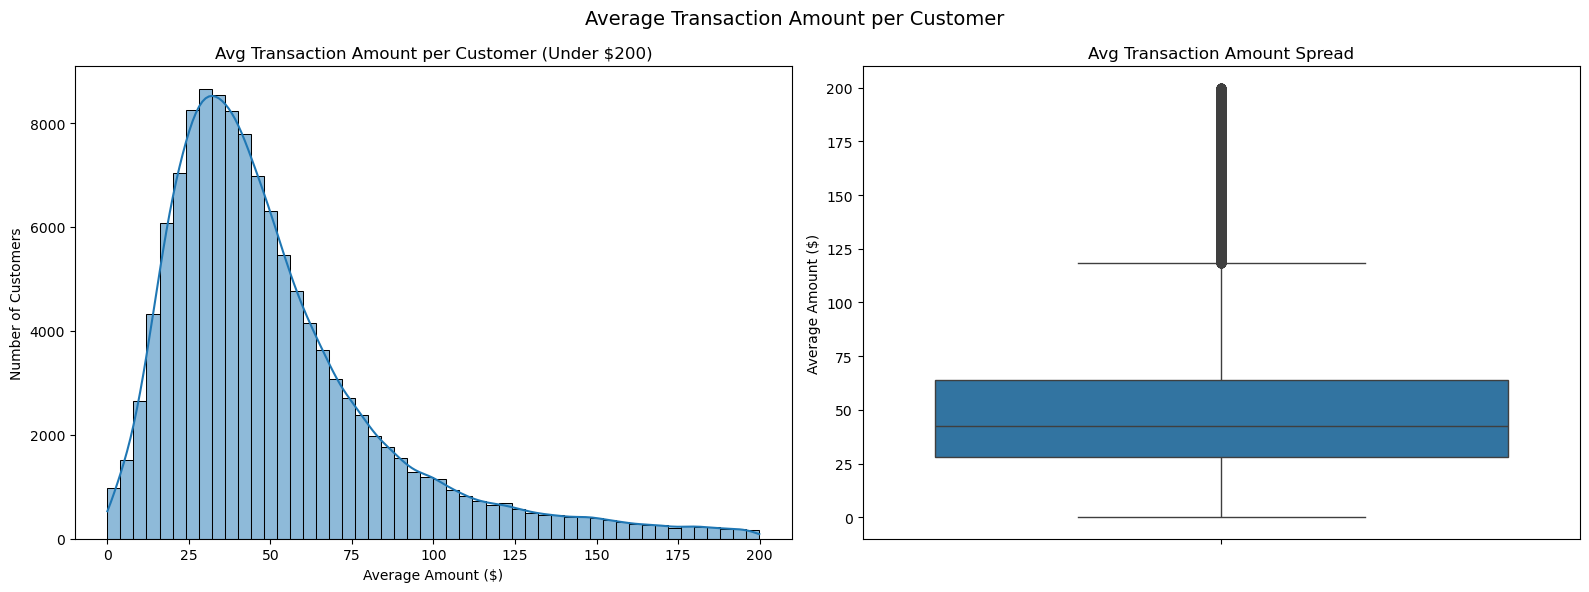

In [68]:
# Avg transaction amount per customer (distribution)
df_avg_per_customer = con.execute("""
    SELECT CustomerID, 
           ROUND(AVG(Amount_Completed), 2) AS avg_amount,
           COUNT(*) AS txn_count
    FROM silver.transactions
    GROUP BY CustomerID
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

filtered_avg = df_avg_per_customer[df_avg_per_customer['avg_amount'] < 200]
sns.histplot(data=filtered_avg, x='avg_amount', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Avg Transaction Amount per Customer (Under $200)')
axes[0].set_xlabel('Average Amount ($)')
axes[0].set_ylabel('Number of Customers')

sns.boxplot(data=filtered_avg, y='avg_amount', ax=axes[1])
axes[1].set_title('Avg Transaction Amount Spread')
axes[1].set_ylabel('Average Amount ($)')

plt.suptitle('Average Transaction Amount per Customer', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/transactions/txnamounts200.png", dpi=150, bbox_inches='tight')
plt.show()

In [109]:
query = con.execute("""SELECT *
FROM silver.transactions 
WHERE ATM_City_State IS NULL 
   OR ATM_City_State = '' 
   OR ATM_City_State = 'NA'
""").df()

print(query)

                       ATM_Address ATM_City_State Merchant_Category  \
0              90 WOODLANDS INDUST             NA              5817   
1                       Hurst Lane             NA              8911   
2   Room B3, 19/F, Tung,SHEUNG WAN            NaN              5691   
3     HOLLY HOUSE, HIGH R,GRANTHAM            NaN              5734   
4              90 WOODLANDS INDUST             NA              5817   
..                             ...            ...               ...   
85             90 WOODLANDS INDUST             NA              5817   
86             7 Straits View, Mar             NA              5816   
87             7 Straits View, Mar             NA              5816   
88   KOWLOON HONG KONG,WORKSHOP 60            NaN              5815   
89             7 Straits View, Mar             NA              5816   

       Merchant_Name Transaction_Code Transaction_Code_Description  \
0           Netshort               40               D/C SETTLEMENT   
1      

In [1]:
con.close()

NameError: name 'con' is not defined